In [ ]:
import json
import sys
import matplotlib.pyplot as plt
from pathlib import Path


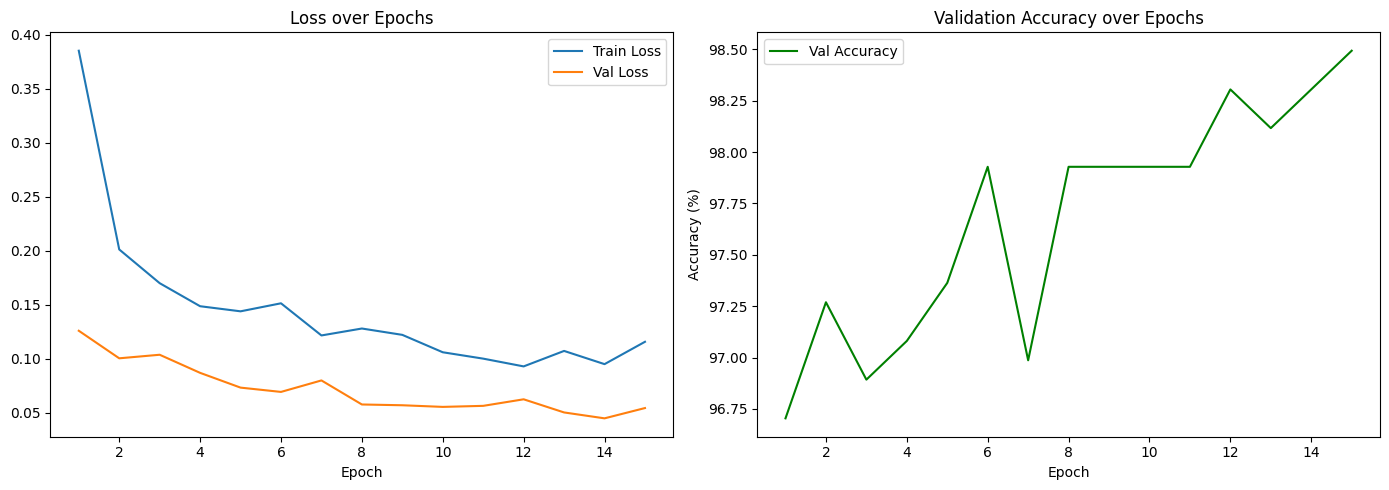

In [8]:
base_dir = Path().resolve().parent 
history_path = base_dir / "outputs" / "history.json"
output_dir = base_dir / "outputs"
output_dir.mkdir(exist_ok=True)

with open(history_path) as f:
    history = json.load(f)
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train Loss")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(epochs, history["val_acc"], color="green", label="Val Accuracy")
axes[1].set_title("Validation Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / "training_history.png", dpi=150)
plt.show()

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from src.dataset import get_dataloaders
from src.model import build_model
import sys
from pathlib import Path

# Go up one level from notebooks/ to project root
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))


               precision    recall  f1-score   support

  freshapples       0.96      0.98      0.97       172
  freshbanana       0.99      1.00      1.00       155
 freshoranges       0.99      1.00      0.99       203
 rottenapples       0.97      0.95      0.96       177
 rottenbanana       1.00      0.99      0.99       177
rottenoranges       0.98      0.98      0.98       178

     accuracy                           0.98      1062
    macro avg       0.98      0.98      0.98      1062
 weighted avg       0.98      0.98      0.98      1062



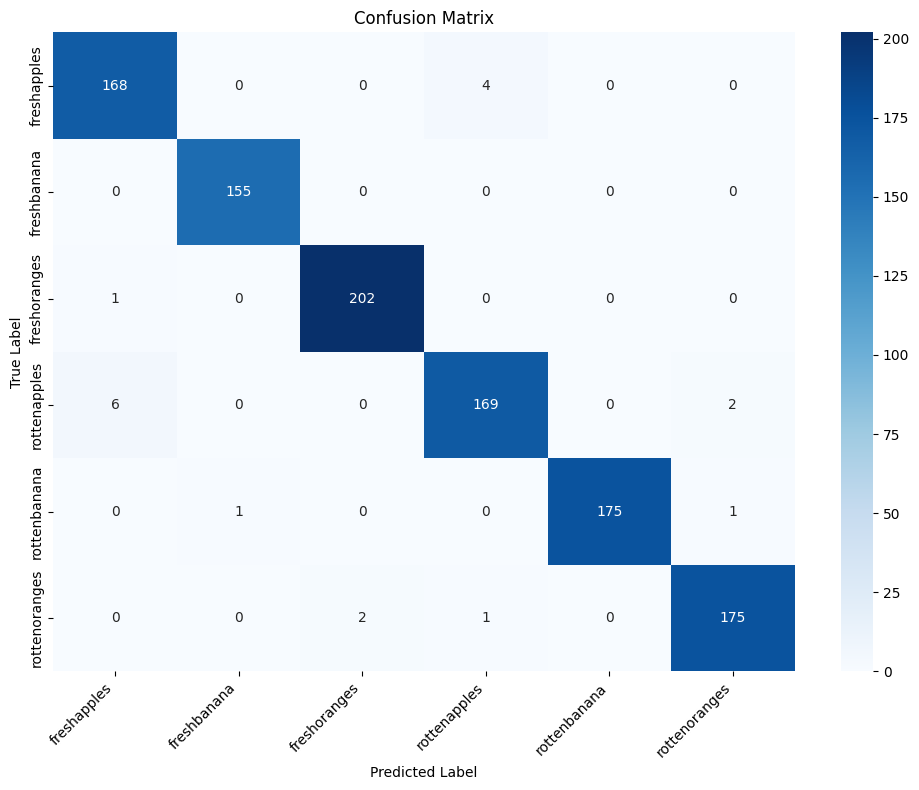

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, val_loader, classes = get_dataloaders(str(ROOT / "data/raw/dataset"), batch_size=32)

model = build_model(num_classes=len(classes))
model.load_state_dict(torch.load(str(ROOT / "best_model.pth"), map_location=device))
model = model.to(device)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(str(ROOT /"outputs/confusion_matrix.png"), dpi=150)
plt.show()

In [26]:
from pathlib import Path
import sys
import torch

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# project root
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))



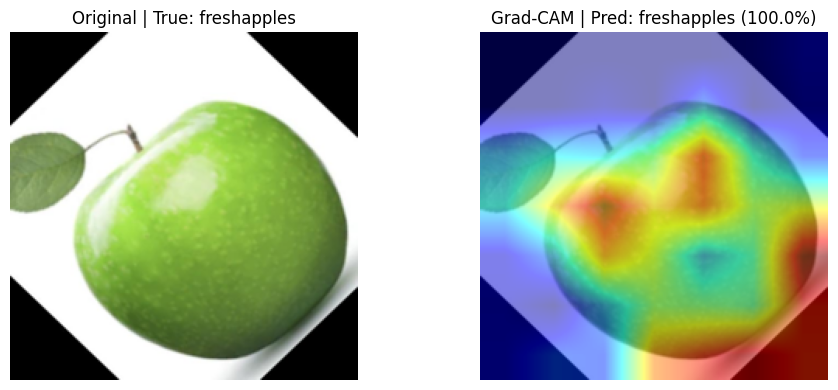

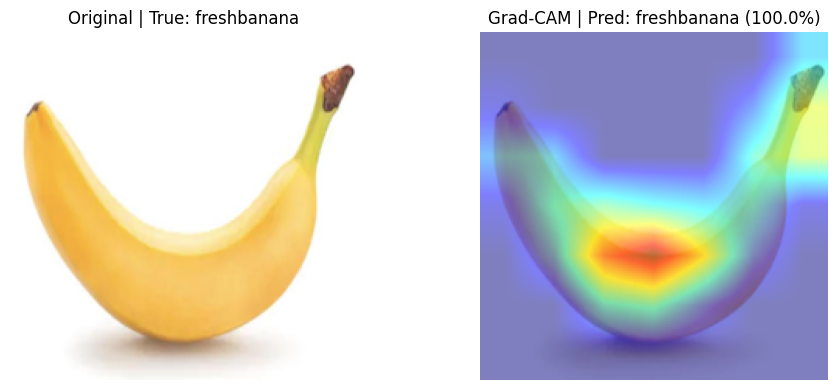

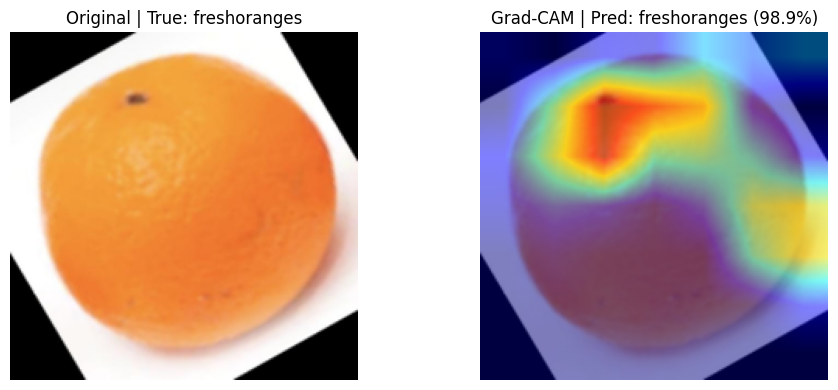

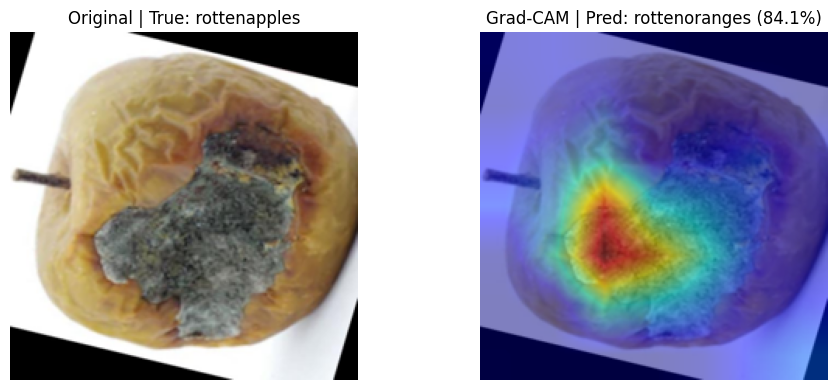

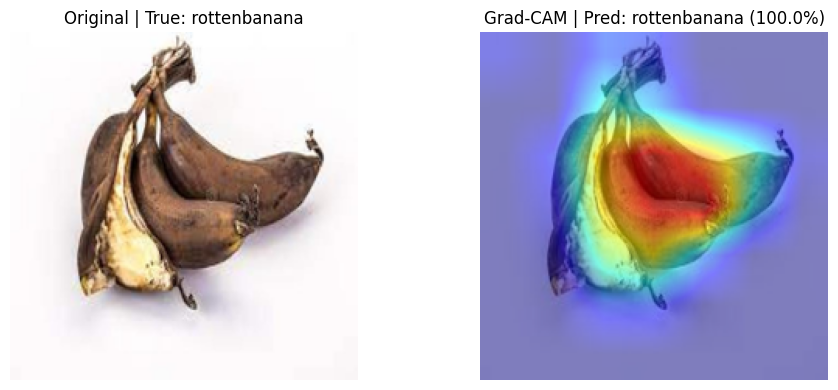

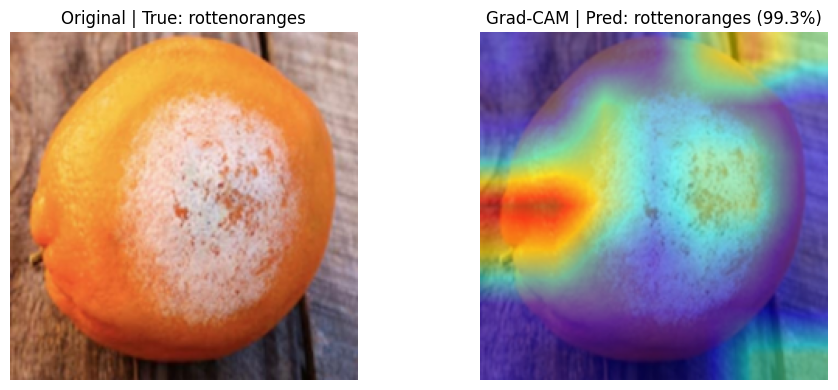

In [29]:
target_layer = [model.features[-1]]

cam = GradCAMPlusPlus(model=model, target_layers=target_layer)

def apply_gradcam(image_path: str, true_label: str):
    raw_img = Image.open(image_path).convert("RGB").resize((224, 224))
    img_array = np.array(raw_img) / 255.0

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    input_tensor = preprocess(raw_img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    model.eval()

    with torch.enable_grad():
        output = model(input_tensor)

    pred_idx = output.argmax(dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][pred_idx].item()

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(pred_idx)]
    )

    cam_image = show_cam_on_image(
        img_array.astype(np.float32),
        grayscale_cam[0],
        use_rgb=True
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(raw_img)
    axes[0].set_title(f"Original | True: {true_label}")
    axes[0].axis("off")

    axes[1].imshow(cam_image)
    axes[1].set_title(f"Grad-CAM | Pred: {classes[pred_idx]} ({confidence:.1%})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    
    output_dir = ROOT / "outputs/gradcam"
    output_dir.mkdir(parents=True, exist_ok=True)

    filename = Path(image_path).stem

    # salvar imagem original
    raw_img.save(output_dir / f"{filename}_original.jpg")

    # salvar gradcam
    plt.imsave(output_dir / f"{filename}_gradcam.jpg", cam_image)


dataset_path = ROOT / "data/raw/dataset/valid"

for class_name in sorted(dataset_path.iterdir()):
    if not class_name.is_dir():
        continue

    images = list(class_name.glob("*"))

    if len(images) == 0:
        continue

    sample = images[0]
    apply_gradcam(str(sample), class_name.name)